In [2]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score, 
    precision_recall_fscore_support
)
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm as sklearn_svm
import xgboost as xgb
import shap

# Tells Jupyter to render plots inline directly under the cell
%matplotlib inline
sns.set_theme(style="whitegrid")

In [3]:
def load_and_preprocess_data():
    path = r"C:\Users\mad\miniconda3\envs\xai_ids\cicids2017\Week_filtered.csv"
    df = pd.read_csv(path, skipinitialspace=True, low_memory=False)
    df.drop([len(df)-1], inplace=True)
    
    label_mapping = {
        'DoS Hulk': 'DoS', 'DDoS': 'DoS', 'DoS GoldenEye': 'DoS',
        'DoS slowloris': 'DoS', 'DoS Slowhttptest': 'DoS', 'Heartbleed': 'DoS',
        'Web Attack_Brute Force': 'WebAttack', 'Web Attack_XSS': 'WebAttack',
        'Web Attack_Sql Injection': 'WebAttack',
        'FTP-Patator': 'BruteForce', 'SSH-Patator': 'BruteForce'
    }
    df['Label'] = df['Label'].replace(label_mapping)
    df["Label"] = df["Label"].apply(lambda x: 0 if x == "BENIGN" else 1)
    
    columns_to_drop = ["Flow ID", "Source IP", "Destination IP", "Timestamp"]
    df.drop(columns=columns_to_drop, inplace=True, errors='ignore')
    
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)
    
    categorical_cols = df.drop(columns=["Label"]).select_dtypes(include=['object']).columns
    if len(categorical_cols) > 0:
        df = pd.get_dummies(df, columns=categorical_cols)
        
    return df

df_clean = load_and_preprocess_data()

X_all = df_clean.drop(columns=["Label"])
y_all = df_clean["Label"].values
feature_names_all = X_all.columns.tolist()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_all.values, y_all, train_size=0.8, test_size=0.2, random_state=0, stratify=y_all
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

print(f"Data Loaded Successfully! Training shape: {X_train_scaled.shape}")

Data Loaded Successfully! Training shape: (434452, 78)


In [4]:
performance_metrics = {}

def evaluate_model(model, name, X_tr, y_tr, X_te, y_te):
    print(f"--- Training and Evaluating: {name} ---")
    start_train = time.time()
    model.fit(X_tr, y_tr)
    end_train = time.time()
    train_time = end_train - start_train
    
    start_pred = time.time()
    y_pred = model.predict(X_te)
    end_pred = time.time()
    pred_time = end_pred - start_pred
    
    acc = accuracy_score(y_te, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_te, y_pred, average='weighted')
    
    performance_metrics[name] = {
        'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1,
        'Train Time (s)': train_time, 'Prediction Time (s)': pred_time,
        'Predictions': y_pred, 'Model Object': model
    }
    return y_pred

# Initialize and run
dt_model = DecisionTreeClassifier(random_state=0)
rf_model = RandomForestClassifier(random_state=0)
xg_model = xgb.XGBClassifier(n_estimators=10, random_state=0)

y_pred_dt = evaluate_model(dt_model, 'Decision Tree', X_train_scaled, y_train, X_test_scaled, y_test)
y_pred_rf = evaluate_model(rf_model, 'Random Forest', X_train_scaled, y_train, X_test_scaled, y_test)
y_pred_xg = evaluate_model(xg_model, 'XGBoost', X_train_scaled, y_train, X_test_scaled, y_test)

--- Training and Evaluating: Decision Tree ---
--- Training and Evaluating: Random Forest ---
--- Training and Evaluating: Extra Trees ---
--- Training and Evaluating: XGBoost ---


In [5]:
from sklearn.ensemble import StackingClassifier

print("\n--- Initializing and Training Genuine Stacking Ensemble ---")

# 1. Define the base learners matching your methodology
base_learners = [
    ('dt', DecisionTreeClassifier(random_state=0)),
    ('rf', RandomForestClassifier(random_state=0)),
    ('xg', xgb.XGBClassifier(n_estimators=10, random_state=0))
]

# 2. Define the true final meta-estimator
meta_learner = xgb.XGBClassifier(random_state=0, eval_metric='logloss')

# 3. Build the native Stacking Classifier
# cv=5 uses 5-fold cross-validation internally to generate unbiased meta-features
stacking_pipeline = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5,
    n_jobs=-1,
    passthrough=False # Set to True if you want the meta-learner to see original features too
)

# 4. Train and evaluate using the unified engine function
y_pred_stk = evaluate_model(
    model=stacking_pipeline, 
    name='Stacking Model', 
    X_tr=X_train_scaled, 
    y_tr=y_train, 
    X_te=X_test_scaled, 
    y_te=y_test
)


--- Initializing and Training Genuine Stacking Ensemble ---
--- Training and Evaluating: Stacking Model ---


,Accuracy,Precision,Recall,F1-Score,Train Time (s),Prediction Time (s)
Decision Tree,0.999383,0.999383,0.999383,0.999383,32.421725,0.059354
Random Forest,0.999438,0.999438,0.999438,0.999438,149.984,0.799665
Extra Trees,0.99896,0.99896,0.99896,0.99896,91.269543,1.118065
XGBoost,0.996732,0.996732,0.996732,0.99673,1.520399,0.037099
Stacking Model,0.999512,0.999512,0.999512,0.999512,482.735467,1.438285


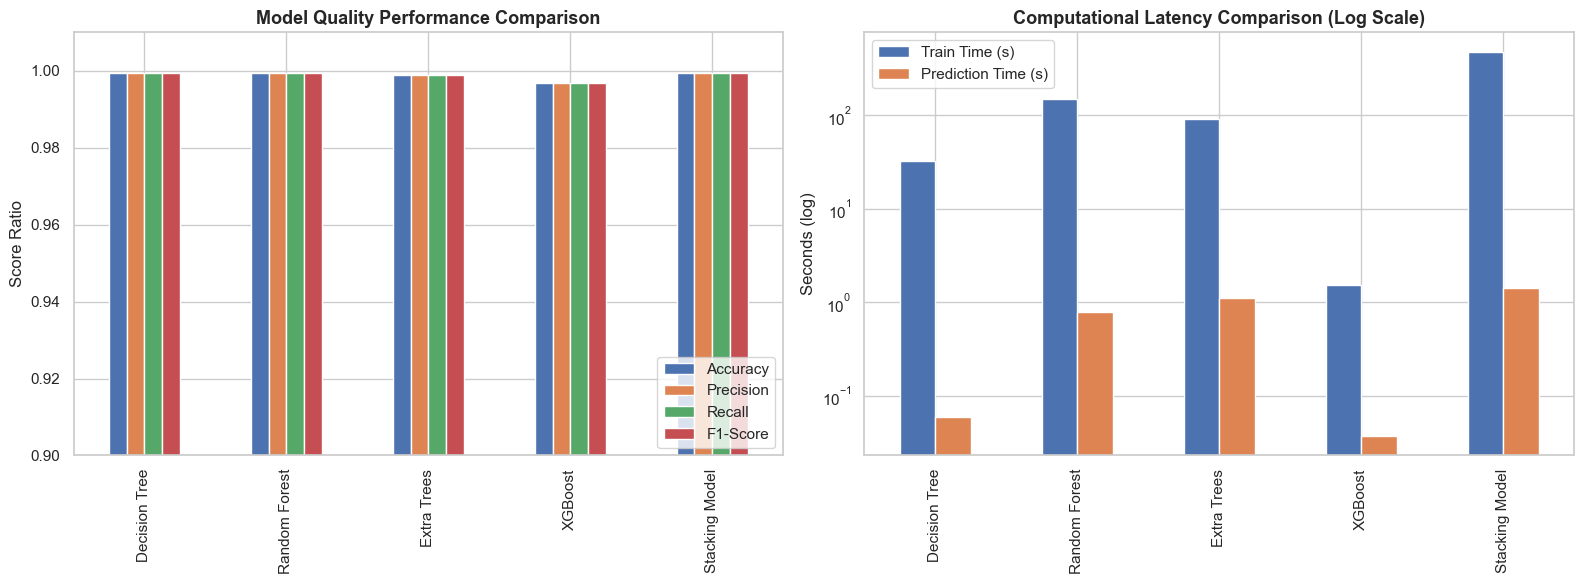

In [6]:
df_metrics = pd.DataFrame(performance_metrics).T.drop(columns=['Predictions', 'Model Object'])

# Render the dataframe cleanly as an interactive Jupyter Table
display(df_metrics)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
df_metrics[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(kind='bar', ax=axes[0])
axes[0].set_title("Model Quality Performance Comparison", fontsize=13, weight='bold')
axes[0].set_ylabel("Score Ratio")
axes[0].set_ylim(0.9, 1.01)
axes[0].legend(loc='lower right')

df_metrics[['Train Time (s)', 'Prediction Time (s)']].plot(kind='bar', logy=True, ax=axes[1])
axes[1].set_title("Computational Latency Comparison (Log Scale)", fontsize=13, weight='bold')
axes[1].set_ylabel("Seconds (log)")
plt.tight_layout()
plt.show()

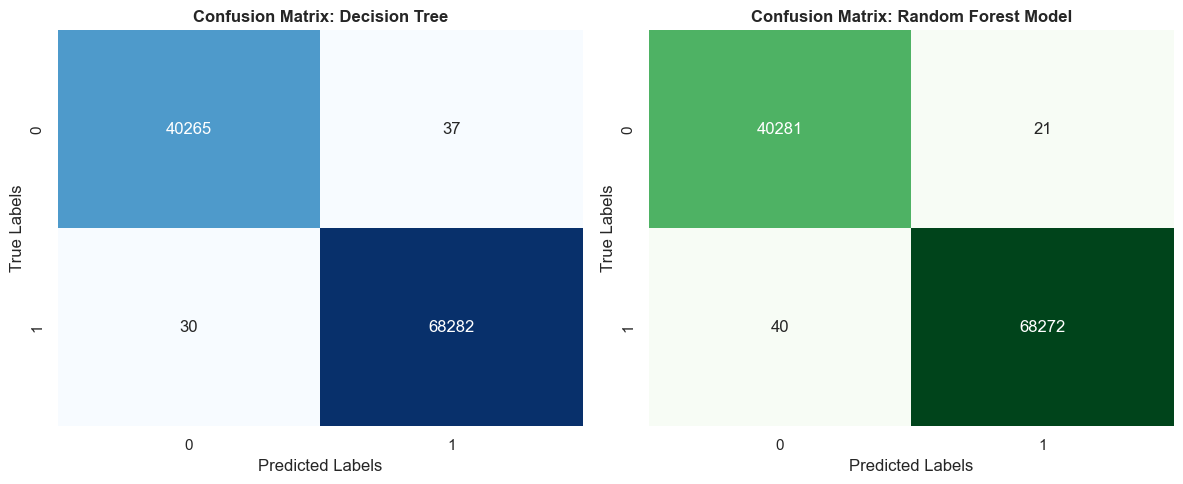

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt=".0f", cmap="Blues", ax=axes[0], cbar=False)
axes[0].set_title("Confusion Matrix: Decision Tree", fontsize=12, weight='bold')
axes[0].set_xlabel("Predicted Labels")
axes[0].set_ylabel("True Labels")

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt=".0f", cmap="Greens", ax=axes[1], cbar=False)
axes[1].set_title("Confusion Matrix: Random Forest Model", fontsize=12, weight='bold')
axes[1].set_xlabel("Predicted Labels")
axes[1].set_ylabel("True Labels")

plt.tight_layout()
plt.show()

Computing SHAP values...


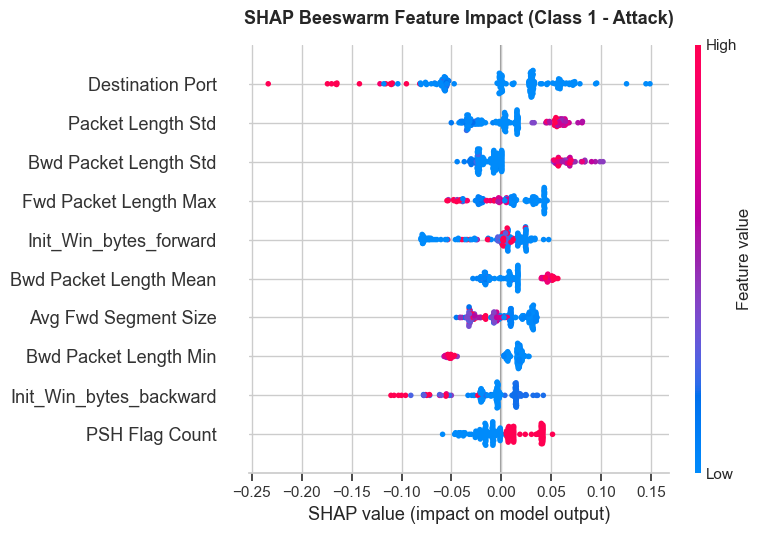

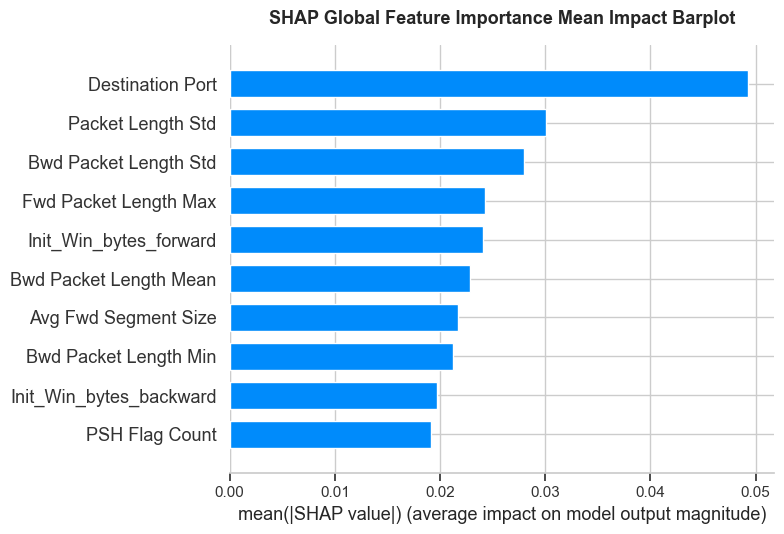

In [9]:
print("Computing SHAP values...")
X_sample = shap.utils.sample(X_test_scaled, 200, random_state=0)
explainer = shap.TreeExplainer(performance_metrics['Random Forest']['Model Object'])
shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_values_class1 = shap_values[:, :, 1]
else:
    shap_values_class1 = shap_values

X_sample_df = pd.DataFrame(X_sample, columns=feature_names_all)

# Beeswarm
plt.figure(figsize=(12, 6))
plt.title("SHAP Beeswarm Feature Impact (Class 1 - Attack)", fontsize=13, pad=15, weight='bold')
shap.summary_plot(shap_values_class1, X_sample_df, max_display=10, show=False)
plt.tight_layout()
plt.show()

# Global Barplot
plt.figure(figsize=(12, 6))
plt.title("SHAP Global Feature Importance Mean Impact Barplot", fontsize=13, pad=15, weight='bold')
shap.summary_plot(shap_values_class1, X_sample_df, plot_type="bar", max_display=10, show=False)
plt.tight_layout()
plt.show()

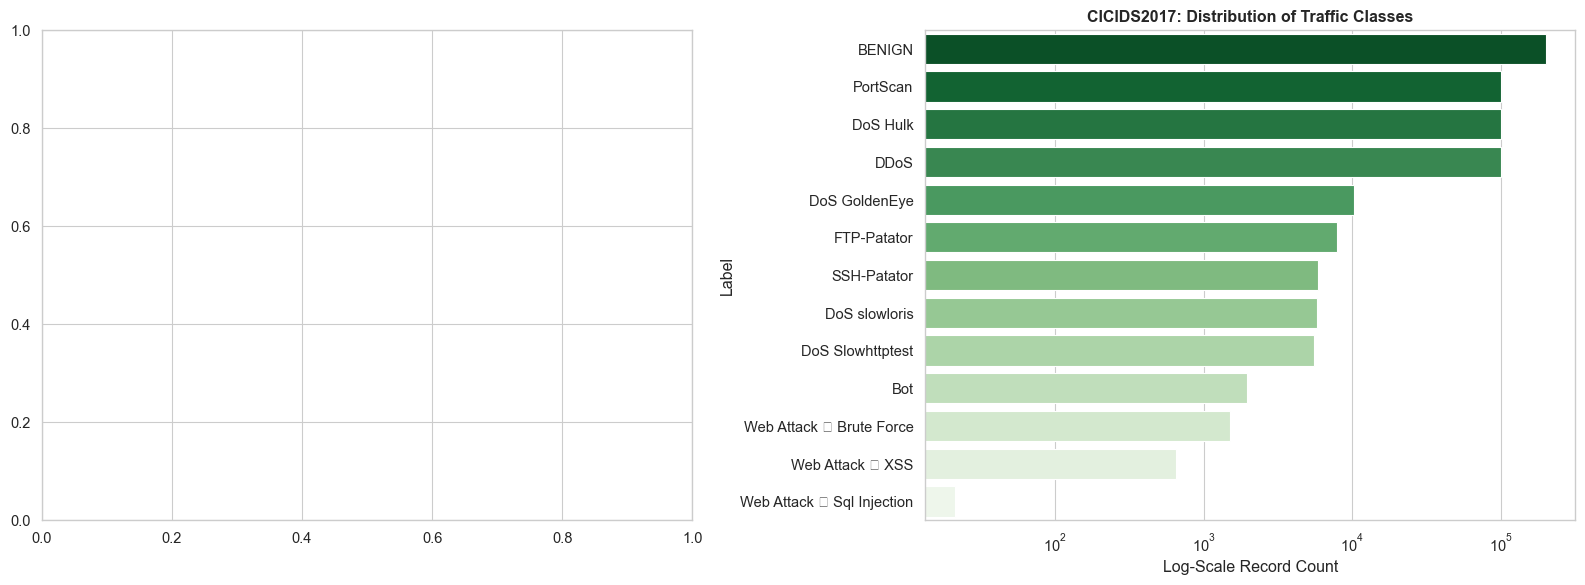

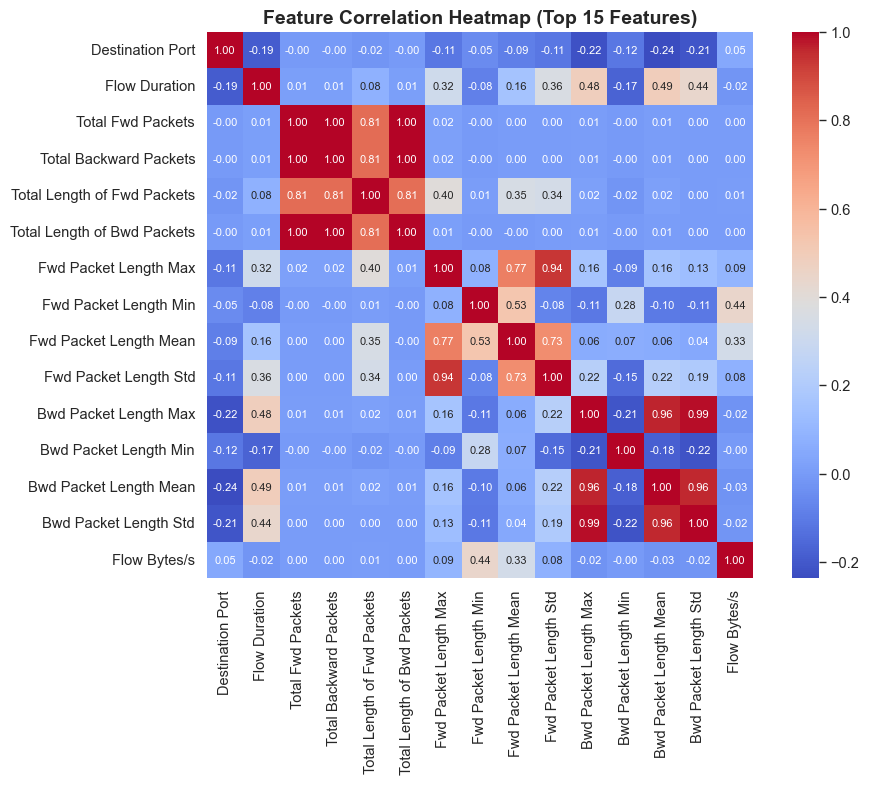

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set clean visualization parameters for papers
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)
fig_color = "#2b5c8f"

path = r"C:\Users\mad\miniconda3\envs\xai_ids\cicids2017\Week_filtered.csv"
df = pd.read_csv(path, skipinitialspace=True, low_memory=False)
df.drop([len(df)-1], inplace=True)

# 3. Standardize Column Names 
df.columns = df.columns.str.strip()

# --- Visual 1: Attack Types vs. Normal Counts ---
# Note: For this visual, use your UNCLEANED or raw DataFrames before you drop 'attack_cat' or 'Label'
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# CICIDS2017 Distribution (Assuming you loaded raw df beforehand with 'Label' column)
# Standard classes include BENIGN, DDoS, PortScan, Bot, Infiltration, Web Attack, etc.
if 'Label' in df.columns:
    cic_counts = df['Label'].value_counts()
    sns.barplot(x=cic_counts.values, y=cic_counts.index, ax=axes[1], palette="Greens_r")
    axes[1].set_title("CICIDS2017: Distribution of Traffic Classes", fontweight='bold')
    axes[1].set_xlabel("Log-Scale Record Count")
    axes[1].set_xscale('log')
else:
    axes[1].text(0.5, 0.5, "CICIDS2017 'Label' column not found", ha='center')

plt.tight_layout()
plt.show()


# Showing correlation of top features to keep the visual readable
plt.figure(figsize=(10, 8))
# Identify numeric columns from your scaled feature matrix
numeric_cols = df.select_dtypes(include=[np.number]).columns[:15] # Top 15 features for clean viewing
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True,
            annot_kws={"size": 8})
plt.title("Feature Correlation Heatmap (Top 15 Features)", fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()